# Smart Finance - Análise de Comportamento Financeiro

##  Exploração e Limpeza dos Dados (EDA)

### Objetivo

Realizar a inspeção inicial dos datasets, verificar sua qualidade, identificar possíveis inconsistências e preparar os dados para as próximas etapas de Ciência de Dados.

In [7]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [8]:
# ============================================================
# LEITURA DOS DADOS (Smart Finance)
# ============================================================

#usuarios = pd.read_csv("data/raw/usuarios.csv")
#transacoes = pd.read_csv("data/raw/transacoes.csv")

In [9]:
# ============================================================
# LEITURA DOS DADOS (colab)
# ============================================================

usuarios = pd.read_csv(f"{BASE}/raw/usuarios.csv")
transacoes = pd.read_csv(f"{BASE}/raw/transacoes.csv")

In [10]:
from google.colab import drive
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/Hackatona G9 Finance AI/data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ============================================================
# VISÃO GERAL DOS DATASETS
# ============================================================

print("USUÁRIOS:", usuarios.shape)
print("TRANSAÇÕES:", transacoes.shape)

display(usuarios.head())

display(transacoes.head())

USUÁRIOS: (1000, 22)
TRANSAÇÕES: (39938, 17)


,usuario_id,idade,sexo,estado_civil,dependentes,cidade,estado,profissao,escolaridade,renda_mensal,outras_rendas,nivel_endividamento,score_credito,saldo_medio_conta,limite_cartao,frequencia_poupanca,percentual_renda_investida,tempo_emprego_anos,possui_financiamento,possui_imovel,possui_veiculo,perfil_financeiro
0,1,40,Masculino,Divorciado,2,Belo Horizonte,MG,Analista de TI,Médio,9214.53,1013.56,27.98,562,3401.85,6849.44,Sempre,7.90,0.9,Não,Não,Não,Em observação
1,2,41,Masculino,Solteiro,2,Duque de Caxias,RJ,Recepcionista,Fundamental,1812.22,0.00,59.68,397,299.94,1343.19,Nunca,1.35,0.5,Não,Não,Sim,Em risco
2,3,40,Feminino,Casado,0,Guarulhos,SP,Analista de TI,Superior,7668.81,691.22,35.69,550,3406.79,11308.24,Às vezes,9.13,0.6,Sim,Não,Sim,Em observação
3,4,38,Masculino,Divorciado,4,Cuiabá,MT,Analista de TI,Superior,7828.20,0.00,49.59,558,2848.93,9317.56,Frequentemente,10.23,16.1,Não,Não,Sim,Em observação
4,5,27,Feminino,Solteiro,0,Maceió,AL,Empresário,Superior,21743.69,0.00,17.56,700,45557.90,35583.72,Sempre,12.76,0.9,Não,Sim,Não,Saudável


,transacao_id,usuario_id,data_transacao,mes,dia_semana,horario,descricao_transacao,valor_transacao,tipo_transacao,categoria,forma_pagamento,parcelado,numero_parcelas,transacao_recorrente,estabelecimento,cidade,estado
0,1,1,2025-07-25,Julho,Sexta-feira,12:15,Compra online - Burger King (compra à vista),829.09,Despesa,Alimentação,Cartão de Crédito,Não,1,Não,Burger King,Belo Horizonte,MG
1,2,1,2025-08-12,Agosto,Terça-feira,08:50,Transação - Renner (parcelado em 4x),232.37,Despesa,Compras,Cartão de Crédito,Sim,4,Não,Renner,Belo Horizonte,MG
2,3,1,2025-08-14,Agosto,Quinta-feira,17:40,Consumo em CDB Banco Inter (compra à vista),910.31,Despesa,Investimentos,Pix,Não,1,Não,CDB Banco Inter,Belo Horizonte,MG
3,4,1,2025-09-19,Setembro,Sexta-feira,21:50,Débito - Decolar.com,421.92,Despesa,Lazer,Cartão de Débito,Não,1,Não,Decolar.com,Belo Horizonte,MG
4,5,1,2025-09-22,Setembro,Segunda-feira,12:30,Pagamento de conta - Açougue Central,450.77,Despesa,Alimentação,Dinheiro,Não,1,Não,Açougue Central,Belo Horizonte,MG


In [12]:
# ============================================================
# ESTRUTURA DOS DADOS
# ============================================================

usuarios.info()

print("\n" + "="*80 + "\n")

transacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   usuario_id                  1000 non-null   int64  
 1   idade                       1000 non-null   int64  
 2   sexo                        1000 non-null   object 
 3   estado_civil                1000 non-null   object 
 4   dependentes                 1000 non-null   int64  
 5   cidade                      1000 non-null   object 
 6   estado                      1000 non-null   object 
 7   profissao                   1000 non-null   object 
 8   escolaridade                1000 non-null   object 
 9   renda_mensal                1000 non-null   float64
 10  outras_rendas               1000 non-null   float64
 11  nivel_endividamento         1000 non-null   float64
 12  score_credito               1000 non-null   int64  
 13  saldo_medio_conta           1000 n

In [13]:
# ============================================================
# ESTATÍSTICAS DESCRITIVAS
# ============================================================

display(usuarios.describe())

display(transacoes.describe())

,usuario_id,idade,dependentes,renda_mensal,outras_rendas,nivel_endividamento,score_credito,saldo_medio_conta,limite_cartao,percentual_renda_investida,tempo_emprego_anos
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,37.740000,1.055000,7084.113570,298.988660,38.482500,634.952000,6237.033950,10169.124050,9.985270,8.913400
std,288.819436,11.409144,1.143364,5015.925416,776.049806,25.565325,182.321828,9438.767251,11214.440967,8.790324,8.014836
min,1.000000,18.000000,0.000000,1412.000000,0.000000,0.000000,300.000000,-534.640000,248.460000,0.000000,0.000000
25%,250.750000,30.000000,0.000000,3413.572500,0.000000,15.560000,490.750000,782.657500,2988.025000,1.987500,2.400000
50%,500.500000,37.000000,1.000000,5664.220000,0.000000,37.080000,619.500000,2642.900000,6771.650000,7.425000,6.700000
75%,750.250000,45.000000,2.000000,9279.910000,148.860000,56.290000,791.000000,7671.230000,12899.320000,16.935000,13.225000
max,1000.000000,75.000000,4.000000,34653.790000,7503.220000,98.000000,1000.000000,72535.380000,92977.960000,32.000000,34.900000


,transacao_id,usuario_id,valor_transacao,numero_parcelas
count,39938.000000,39938.000000,39938.000000,39938.000000
mean,19969.500000,497.205794,1857.185072,1.133632
std,11529.251862,288.490171,2802.616667,0.936978
min,1.000000,1.000000,8.150000,1.000000
25%,9985.250000,247.000000,295.617500,1.000000
50%,19969.500000,500.000000,773.175000,1.000000
75%,29953.750000,745.000000,2348.367500,1.000000
max,39938.000000,1000.000000,35070.120000,12.000000


In [14]:
# ============================================================
# VALORES AUSENTES
# ============================================================

print("Valores ausentes - Usuários")
display(usuarios.isnull().sum())

print("\nValores ausentes - Transações")
display(transacoes.isnull().sum())

Valores ausentes - Usuários


,0
usuario_id,0
idade,0
sexo,0
estado_civil,0
dependentes,0
cidade,0
estado,0
profissao,0
escolaridade,0
renda_mensal,0



Valores ausentes - Transações


,0
transacao_id,0
usuario_id,0
data_transacao,0
mes,0
dia_semana,0
horario,0
descricao_transacao,0
valor_transacao,0
tipo_transacao,0
categoria,0


In [15]:
# ============================================================
# DUPLICIDADES
# ============================================================

print("Duplicados usuários:", usuarios.duplicated().sum())

print("Duplicados transações:", transacoes.duplicated().sum())

Duplicados usuários: 0
Duplicados transações: 0


In [16]:
# ============================================================
# CONVERSÃO DE TIPOS
# ============================================================

transacoes["data_transacao"] = pd.to_datetime(
    transacoes["data_transacao"],
    errors="coerce"
)

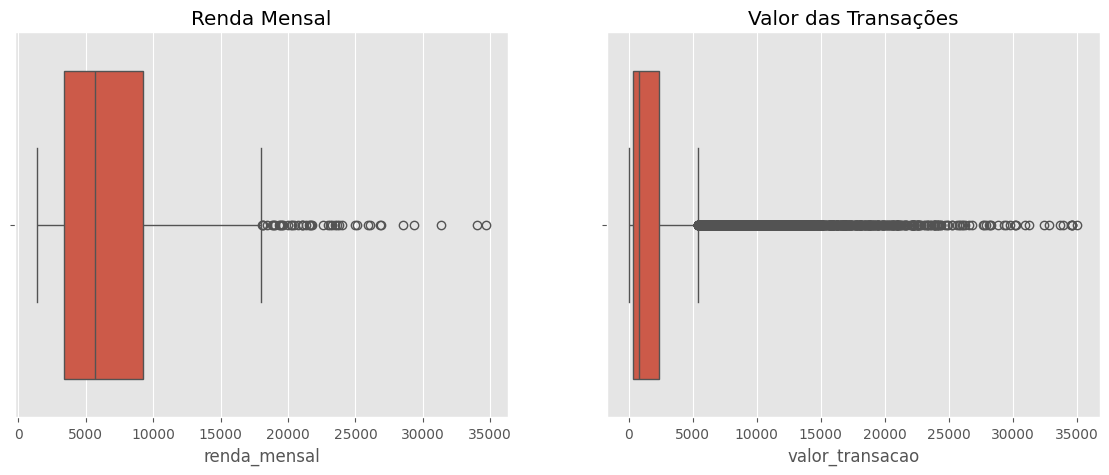

In [17]:
# ============================================================
# OUTLIERS
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    x=usuarios["renda_mensal"],
    ax=ax[0]
)

ax[0].set_title("Renda Mensal")

sns.boxplot(
    x=transacoes["valor_transacao"],
    ax=ax[1]
)

ax[1].set_title("Valor das Transações")

plt.show()

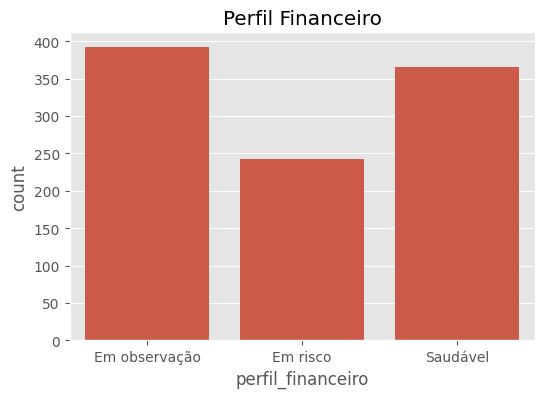

In [18]:
# ============================================================
# DISTRIBUIÇÃO DOS PERFIS FINANCEIROS
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=usuarios,
    x="perfil_financeiro"
)

plt.title("Perfil Financeiro")

plt.show()

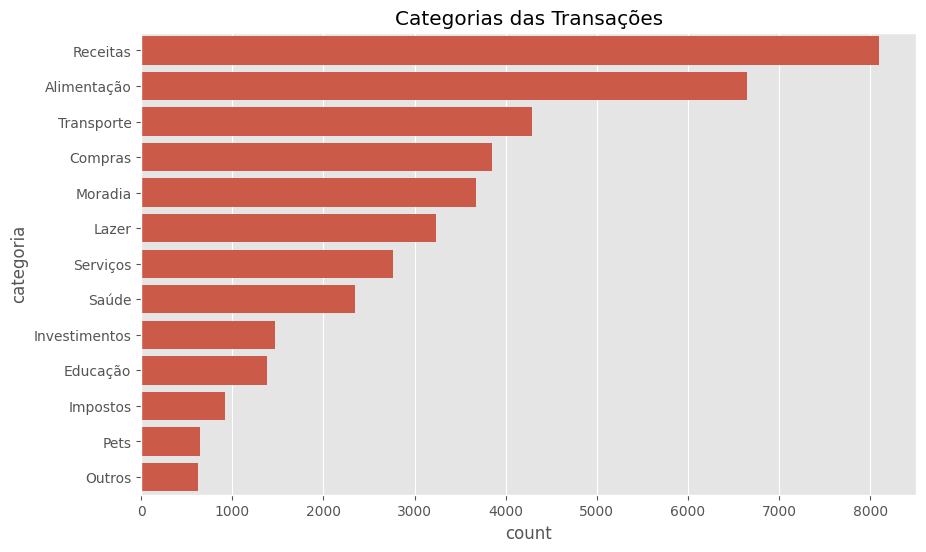

In [19]:
# ============================================================
# DISTRIBUIÇÃO DAS CATEGORIAS
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=transacoes,
    y="categoria",
    order=transacoes["categoria"].value_counts().index
)

plt.title("Categorias das Transações")

plt.show()

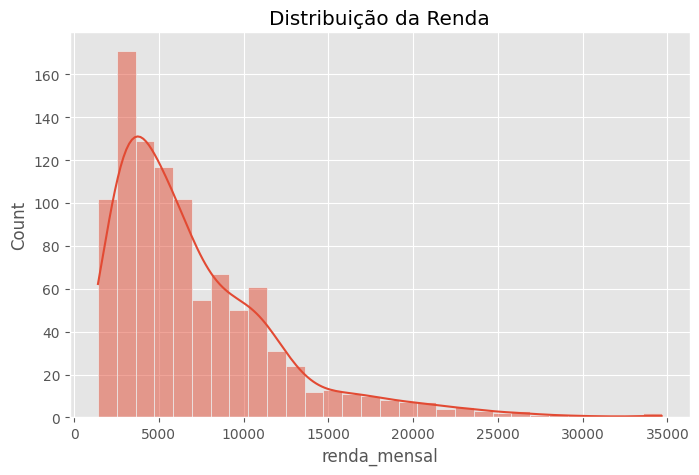

In [20]:
# ============================================================
# DISTRIBUIÇÃO DA RENDA
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    usuarios["renda_mensal"],
    bins=30,
    kde=True
)

plt.title("Distribuição da Renda")

plt.show()

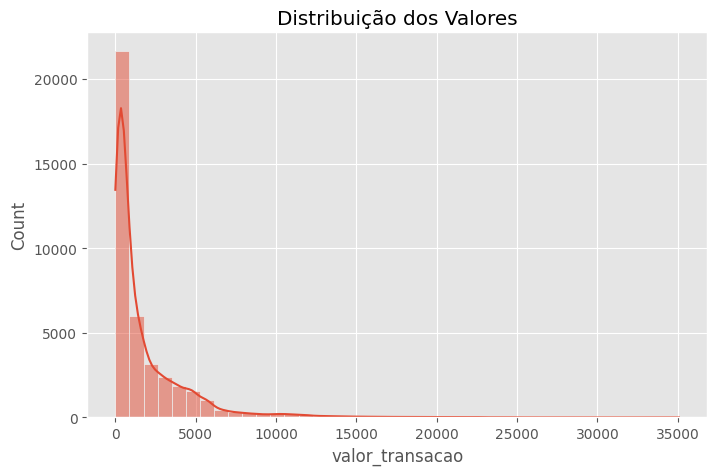

In [21]:
# ============================================================
# DISTRIBUIÇÃO DOS VALORES DAS TRANSAÇÕES
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    transacoes["valor_transacao"],
    bins=40,
    kde=True
)

plt.title("Distribuição dos Valores")

plt.show()

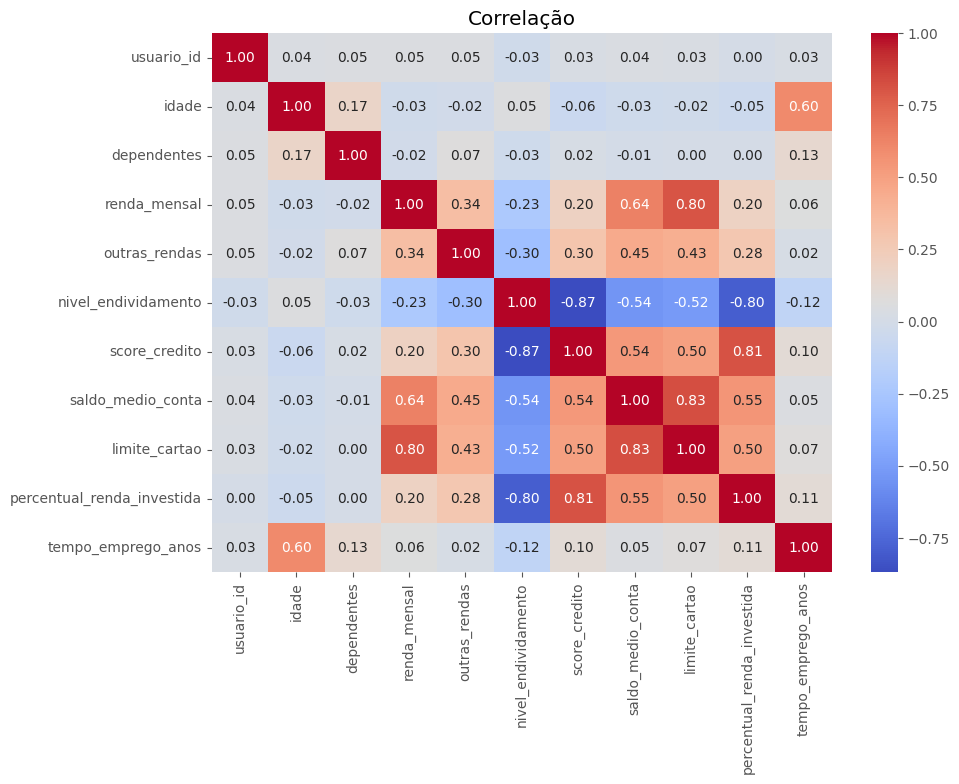

In [22]:
# ============================================================
# CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
# ============================================================

corr = usuarios.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação")

plt.show()

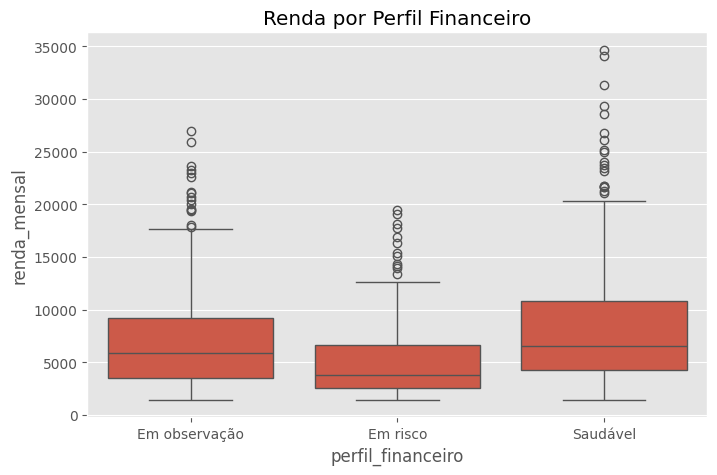

In [23]:
# ============================================================
# RENDA X PERFIL FINANCEIRO
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=usuarios,
    x="perfil_financeiro",
    y="renda_mensal"
)

plt.title("Renda por Perfil Financeiro")

plt.show()

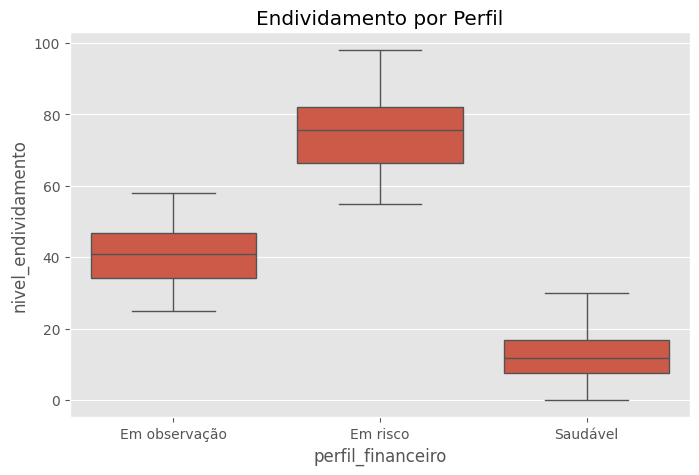

In [24]:
# ============================================================
# ENDIVIDAMENTO X PERFIL
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=usuarios,
    x="perfil_financeiro",
    y="nivel_endividamento"
)

plt.title("Endividamento por Perfil")

plt.show()

In [25]:
# ============================================================
# LIMPEZA DOS DADOS
# ============================================================

usuarios.drop_duplicates(inplace=True)

transacoes.drop_duplicates(inplace=True)

usuarios.dropna(inplace=True)

transacoes.dropna(inplace=True)

In [28]:
# ============================================================
# EXPORTAÇÃO DOS DATASETS TRATADOS
# ============================================================

usuarios.to_csv(
    f"{BASE}/processed/usuarios_tratado.csv",
    index=False
)

transacoes.to_csv(
    f"{BASE}/processed/transacoes_tratado.csv",
    index=False
)

print("Datasets tratados exportados com sucesso.")

Datasets tratados exportados com sucesso.


In [27]:
# ============================================================
# EXPORTAÇÃO DOS DATASETS TRATADOS
# ============================================================

#usuarios.to_csv(
#    "data/processed/usuarios_tratado.csv",
#    index=False
#)

#transacoes.to_csv(
#    "data/processed/transacoes_tratado.csv",
#    index=False
#)

# Conclusão

Nesta etapa foi realizada a exploração e limpeza dos dados.

Principais atividades executadas:

- carregamento dos datasets;
- inspeção estrutural;
- estatísticas descritivas;
- verificação de valores ausentes;
- verificação de duplicidades;
- conversão do tipo da coluna de data;
- análise de outliers;
- distribuição das principais variáveis;
- análise de correlação;
- exportação dos datasets tratados.

Os dados encontram-se preparados para a próxima etapa do projeto: **Tratamento das Variáveis e Engenharia de Atributos**.